In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix

In [ ]:
y_test = np.load('y_test.npy')
model_predictions = {
  'CNB': np.load('y_pred_bcnb.npy'),
  'SVM': np.load('y_pred_bsvm.npy'),
  'RF': np.load('y_pred_brf.npy'),
  'BiLSTM + FastText': np.load('y_pred_bilstm_ft.npy'),
  'IndoBERT': np.load('y_pred_bert.npy'),
  'IndoBERTweet': np.load('y_pred_tweet.npy')
}

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_train = pd.read_csv('/content/train_cleaned_checkpoint.csv')

label_encoder = LabelEncoder()
label_encoder.fit(df_train['label'])

# Class Mapping
class_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Emotion Class Mapping:", class_mapping)

Emotion Class Mapping: {'anger': 0, 'fear': 1, 'happy': 2, 'love': 3, 'sadness': 4}


In [ ]:
for model, y_pred in model_predictions.items():
  print(f"Model {model}:")
  print(classification_report(y_test, y_pred))
  print('-' * 55)

Model CNB:
              precision    recall  f1-score   support

           0       0.63      0.86      0.73       110
           1       0.91      0.60      0.72        65
           2       0.74      0.57      0.65       101
           3       0.72      0.78      0.75        64
           4       0.61      0.61      0.61       100

    accuracy                           0.69       440
   macro avg       0.72      0.69      0.69       440
weighted avg       0.71      0.69      0.69       440

-------------------------------------------------------
Model SVM:
              precision    recall  f1-score   support

           0       0.62      0.78      0.69       110
           1       0.89      0.65      0.75        65
           2       0.63      0.61      0.62       101
           3       0.77      0.73      0.75        64
           4       0.54      0.51      0.52       100

    accuracy                           0.65       440
   macro avg       0.69      0.66      0.67       440

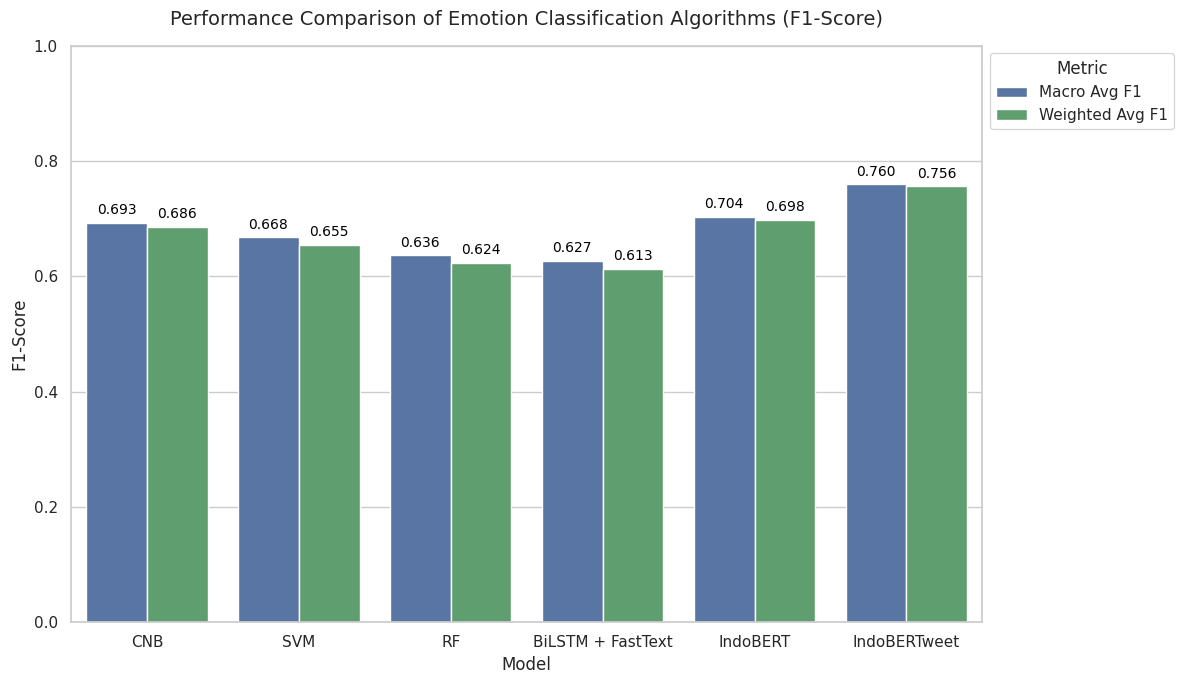

In [ ]:
evaluation_data = []

for model_name, y_pred in model_predictions.items():
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')

    evaluation_data.append({'Model': model_name, 'Metric': 'Macro Avg F1', 'Skor': macro_f1})
    evaluation_data.append({'Model': model_name, 'Metric': 'Weighted Avg F1', 'Skor': weighted_f1})

df_eval = pd.DataFrame(evaluation_data)

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_eval,
    x='Model',
    y='Skor',
    hue='Metric',
    palette=['#4C72B0', '#55A868']
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.3f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=10,
            color='black',
            xytext=(0, 4),
            textcoords='offset points'
        )

plt.title('Performance Comparison of Emotion Classification Algorithms (F1-Score)', fontsize=14, pad=15)
plt.ylabel('F1-Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title='Metric', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.show()

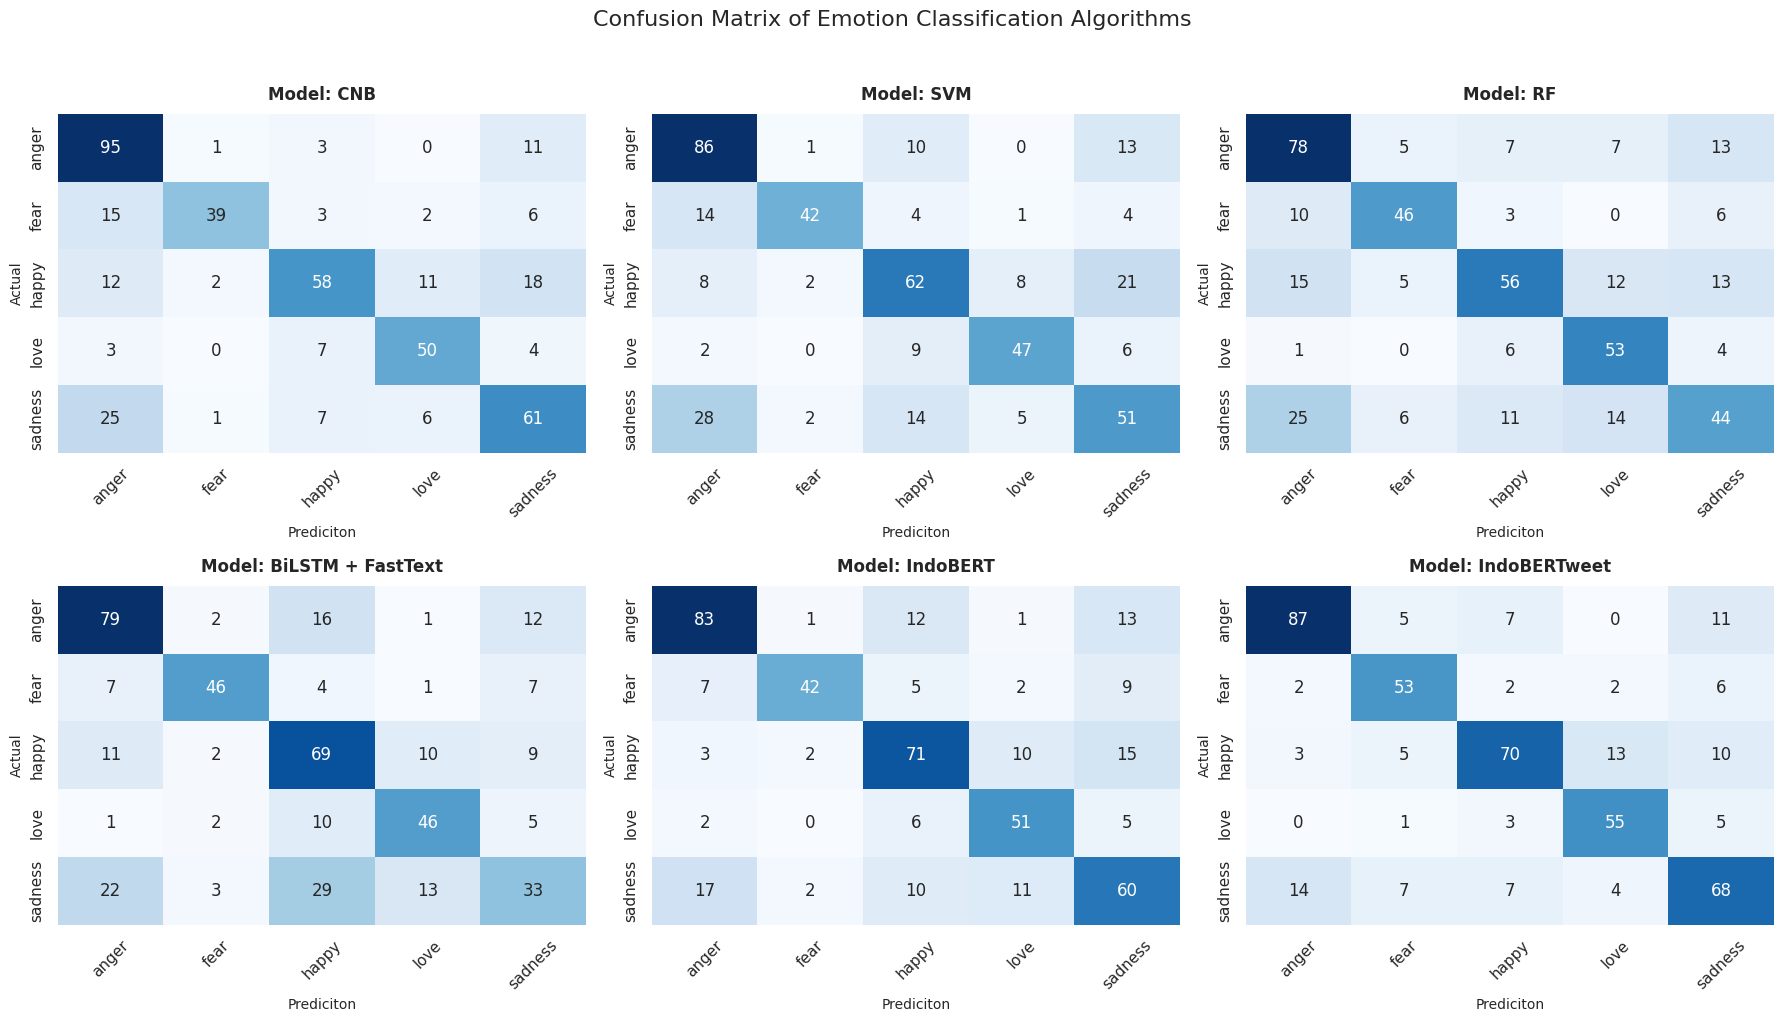

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

label_names = label_encoder.classes_

for idx, (model_name, y_pred) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=axes[idx],
        xticklabels=label_names,
        yticklabels=label_names
    )

    axes[idx].set_title(f'Model: {model_name}', fontsize=12, pad=10, fontweight='bold')
    axes[idx].set_xlabel('Prediciton', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrix of Emotion Classification Algorithms', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

pred_model_1 = model_predictions['CNB']
pred_model_2 = model_predictions['IndoBERTweet']
actual = y_test

b = np.sum((pred_model_1 != actual) & (pred_model_2 == actual))
c = np.sum((pred_model_1 == actual) & (pred_model_2 != actual))

contingency_table = [[0, c],
                     [b, 0]]

result = mcnemar(contingency_table, exact=False, correction=True)

print("McNemar's Test: CNB vs IndoBERTweet")
print(f"Chi-Square Statistic: {result.statistic:.4f}")
print(f"p-value: {result.pvalue:.4e}")

McNemar's Test: CNB vs IndoBERTweet
Chi-Square Statistic: 7.3772
p-value: 6.6056e-03


In [ ]:
if result.pvalue < 0.05:
    print("Kesimpulan: Perbedaan kinerja antara CNB dan IndoBERTweet SIGNIFIKAN secara statistik (Tolak H0).")
else:
    print("Kesimpulan: Perbedaan kinerja TIDAK SIGNIFIKAN secara statistik (Gagal tolak H0).")

Kesimpulan: Perbedaan kinerja antara CNB dan IndoBERTweet SIGNIFIKAN secara statistik (Tolak H0).
